# VIGITEXTO IA

Modelo de VIGITEXTO IA

In [1]:
get_ipython().system('pip -q install pandas scikit-learn matplotlib joblib gradio')

import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    classification_report,
    accuracy_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
)
import joblib
import numpy as np

In [2]:
from google.colab import files

uploaded = files.upload()
filename = list(uploaded.keys())[0]

try:
    df = pd.read_csv(filename, encoding='utf-8')
except Exception:
    df = pd.read_csv(filename, encoding='latin-1')

if 'v1' in df.columns:
    df = df.rename(columns={'v1': 'label', 'v2': 'text'})

df['label'] = df['label'].replace({
    'spam': 'phishing',
    'ham': 'legitimo'
})

df = df[['text', 'label']]
df.head()

Saving spam.csv to spam.csv


,text,label
0,"Go until jurong point, crazy.. Available only ...",legitimo
1,Ok lar... Joking wif u oni...,legitimo
2,Free entry in 2 a wkly comp to win FA Cup fina...,phishing
3,U dun say so early hor... U c already then say...,legitimo
4,"Nah I don't think he goes to usf, he lives aro...",legitimo


In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    df["text"],
    df["label"],
    test_size=0.2,
    random_state=42
)

Accuracy: 0.9623318385650225

Reporte de clasificación (umbral por defecto 0.5):
              precision    recall  f1-score   support

    legitimo       0.96      1.00      0.98       965
    phishing       1.00      0.72      0.84       150

    accuracy                           0.96      1115
   macro avg       0.98      0.86      0.91      1115
weighted avg       0.96      0.96      0.96      1115



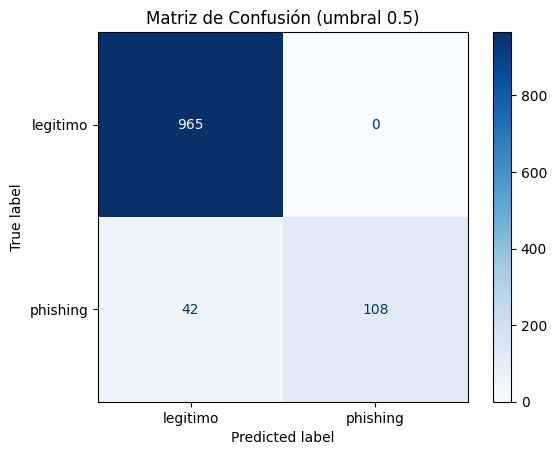

In [4]:
modelo = Pipeline([
    ("tfidf", TfidfVectorizer()),
    ("nb", MultinomialNB())
])

modelo.fit(X_train, y_train)

predicciones = modelo.predict(X_test)

print("Accuracy:", accuracy_score(y_test, predicciones))
print("\nReporte de clasificación (umbral por defecto 0.5):")
print(classification_report(y_test, predicciones))

ConfusionMatrixDisplay(
    confusion_matrix(y_test, predicciones),
    display_labels=modelo.classes_
).plot(cmap="Blues")
plt.title("Matriz de Confusión (umbral 0.5)")
plt.show()


In [5]:
probas_test = modelo.predict_proba(X_test)
indice_phishing = list(modelo.classes_).index("phishing")
prob_phishing_test = probas_test[:, indice_phishing]

print("Comparación de umbrales para la clase 'phishing':\n")
for umbral in [0.5, 0.4, 0.3, 0.25, 0.2, 0.15, 0.1]:
    pred_umbral = np.where(
        prob_phishing_test >= umbral, "phishing", "legitimo"
    )
    reporte = classification_report(
        y_test, pred_umbral, output_dict=True, zero_division=0
    )
    p = reporte["phishing"]["precision"]
    r = reporte["phishing"]["recall"]
    f1 = reporte["phishing"]["f1-score"]
    print(f"Umbral {umbral:>4}  ->  precision={p:.2f}  recall={r:.2f}  f1={f1:.2f}")

Comparación de umbrales para la clase 'phishing':

Umbral  0.5  ->  precision=1.00  recall=0.72  f1=0.84
Umbral  0.4  ->  precision=1.00  recall=0.76  f1=0.86
Umbral  0.3  ->  precision=1.00  recall=0.81  f1=0.89
Umbral 0.25  ->  precision=0.99  recall=0.81  f1=0.89
Umbral  0.2  ->  precision=0.98  recall=0.83  f1=0.90
Umbral 0.15  ->  precision=0.97  recall=0.85  f1=0.90
Umbral  0.1  ->  precision=0.86  recall=0.89  f1=0.88


In [6]:
joblib.dump(modelo, "modelo_phishguard.pkl")

['modelo_phishguard.pkl']

Aplicacion de VIGITEXTO IA

In [7]:
import gradio as gr

UMBRAL_PHISHING = 0.15  # ajustado según tu tabla de comparación de umbrales


def analizar_correo(correo):

    probabilidades = modelo.predict_proba([correo])[0]
    indice_phishing = list(modelo.classes_).index("phishing")
    probabilidad_phishing = probabilidades[indice_phishing] * 100

    # Decisión basada en el umbral ajustado (no en el 0.5 por defecto)
    pred = "phishing" if (probabilidad_phishing / 100) >= UMBRAL_PHISHING else "legitimo"

    indicadores = []
    texto = correo.lower()

    if "http" in texto or "www." in texto:
        indicadores.append("🔗 El SMS contiene enlaces.")

    palabras = [
        "password", "verify", "account", "urgent", "click",
        "login", "bank", "security", "confirm", "limited",
    ]
    encontradas = [p for p in palabras if p in texto]
    if encontradas:
        indicadores.append(
            "⚠ Se detectaron palabras sospechosas: " + ", ".join(encontradas)
        )

    if probabilidad_phishing >= 70:
        riesgo = "🔴 ALTO"
    elif probabilidad_phishing >= UMBRAL_PHISHING * 100:
        riesgo = "🟠 MEDIO"
    else:
        riesgo = "🟢 BAJO"

    if pred == "phishing":
        resultado = "⚠ POSIBLE PHISHING"
        recomendacion = """
• No haga clic en enlaces sospechosos.

• No comparta sus contraseñas.

• Verifique el remitente.

• Contacte a la empresa por canales oficiales.
"""
    else:
        resultado = "✅ SMS LEGÍTIMO"
        recomendacion = """
No se detectaron características típicas de phishing.

Se recomienda verificar siempre el remitente antes de responder.
"""

    return (
        resultado,
        f"{probabilidad_phishing:.2f} %",
        riesgo,
        "\n".join(indicadores) if indicadores else "No se encontraron indicadores sospechosos.",
        recomendacion,
    )

In [8]:
tema = gr.themes.Soft(
    primary_hue="blue",
    secondary_hue="blue",
    neutral_hue="slate",
    font=[
        gr.themes.GoogleFont("Poppins"),
        "sans-serif"
    ]
)

with gr.Blocks(theme=tema, title="VIGITEXTO IA") as demo:

    gr.Markdown("""
    #  VIGITEXTO IA

    ## Sistema Inteligente para la Detección de SMS Phishing
    ### Análisis automático de servicio de mensajes cortos mediante Inteligencia Artificial

    **Prototipo MVP**

    ---
    """)

    gr.Markdown("""
Esta herramienta analiza automáticamente el contenido de un servicio de mensajes cortos y determina si presenta características asociadas a un posible ataque de phishing utilizando un modelo de Machine Learning previamente entrenado.
""")

    with gr.Row():
        with gr.Column(scale=2):
            correo = gr.Textbox(
                lines=16,
                label="📧 SMS",
                placeholder="Pegue aquí el contenido del servicio de mensajes cortos en inglés..."
            )
            analizar = gr.Button("🔍 Analizar SMS", variant="primary")
            limpiar = gr.Button("🗑️ Limpiar")

        with gr.Column(scale=1):
            resultado = gr.Textbox(label="🛡️ Resultado del análisis")
            confianza = gr.Textbox(label="📊 Nivel de confianza")
            riesgo = gr.Textbox(label="🚨 Clasificación del riesgo")
            indicadores = gr.Textbox(lines=6, label="🔍 Indicadores detectados")
            recomendacion = gr.Textbox(lines=6, label="💡 Recomendaciones de seguridad")

    with gr.Accordion("ℹ️ Información del modelo", open=False):
        gr.Markdown(f"""
### Modelo de Machine Learning

- Algoritmo: **TF-IDF + Multinomial Naive Bayes**
- Dataset: **SMS Spam Collection Dataset**
- Umbral de decisión ajustado: **{UMBRAL_PHISHING}** (en vez del 0.5 por defecto)
- Idioma soportado: **Inglés**
- Estado: **Prototipo funcional (MVP)**

---

Esta primera versión fue entrenada únicamente con servicio de mensajes cortos en inglés debido al tiempo disponible durante el desarrollo del prototipo.
""")

    analizar.click(
        fn=analizar_correo,
        inputs=correo,
        outputs=[resultado, confianza, riesgo, indicadores, recomendacion]
    )

    limpiar.click(
        lambda: ("", "", "", "", "", ""),
        outputs=[correo, resultado, confianza, riesgo, indicadores, recomendacion]
    )

demo.launch(share=True)


/tmp/ipykernel_2541/3124094800.py:11: UserWarning: The parameters have been moved from the Blocks constructor to the launch() method in Gradio 6.0: theme. Please pass these parameters to launch() instead.
  with gr.Blocks(theme=tema, title="VIGITEXTO IA") as demo:


Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://55939e634c864b1d08.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
